In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)
from xgboost import XGBClassifier

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Country-data.csv to Country-data (1).csv
Saving data-dictionary.csv to data-dictionary.csv


In [4]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
print(df.shape)
df.info()

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.isnull().sum()
df.describe().T
df.duplicated().sum()

np.int64(0)

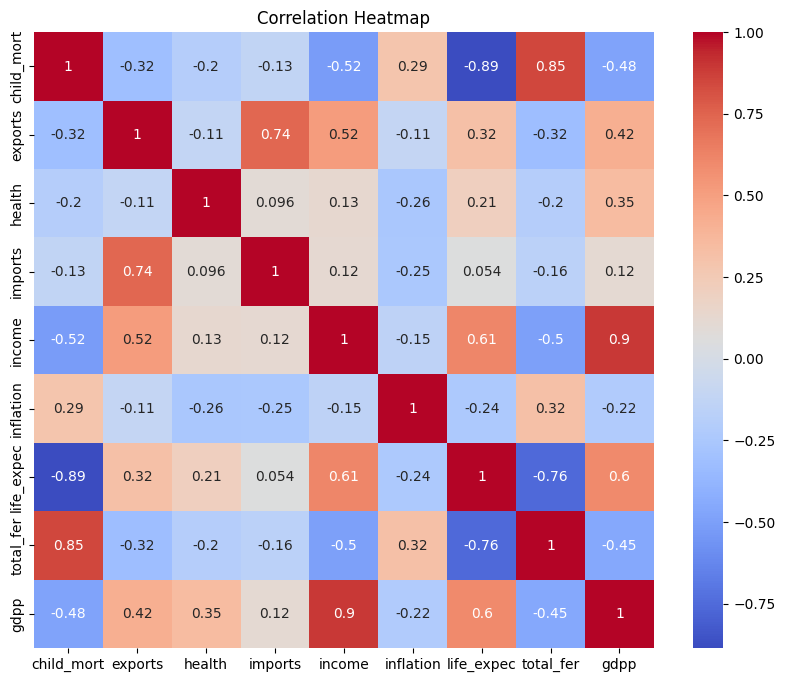

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.drop("country",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

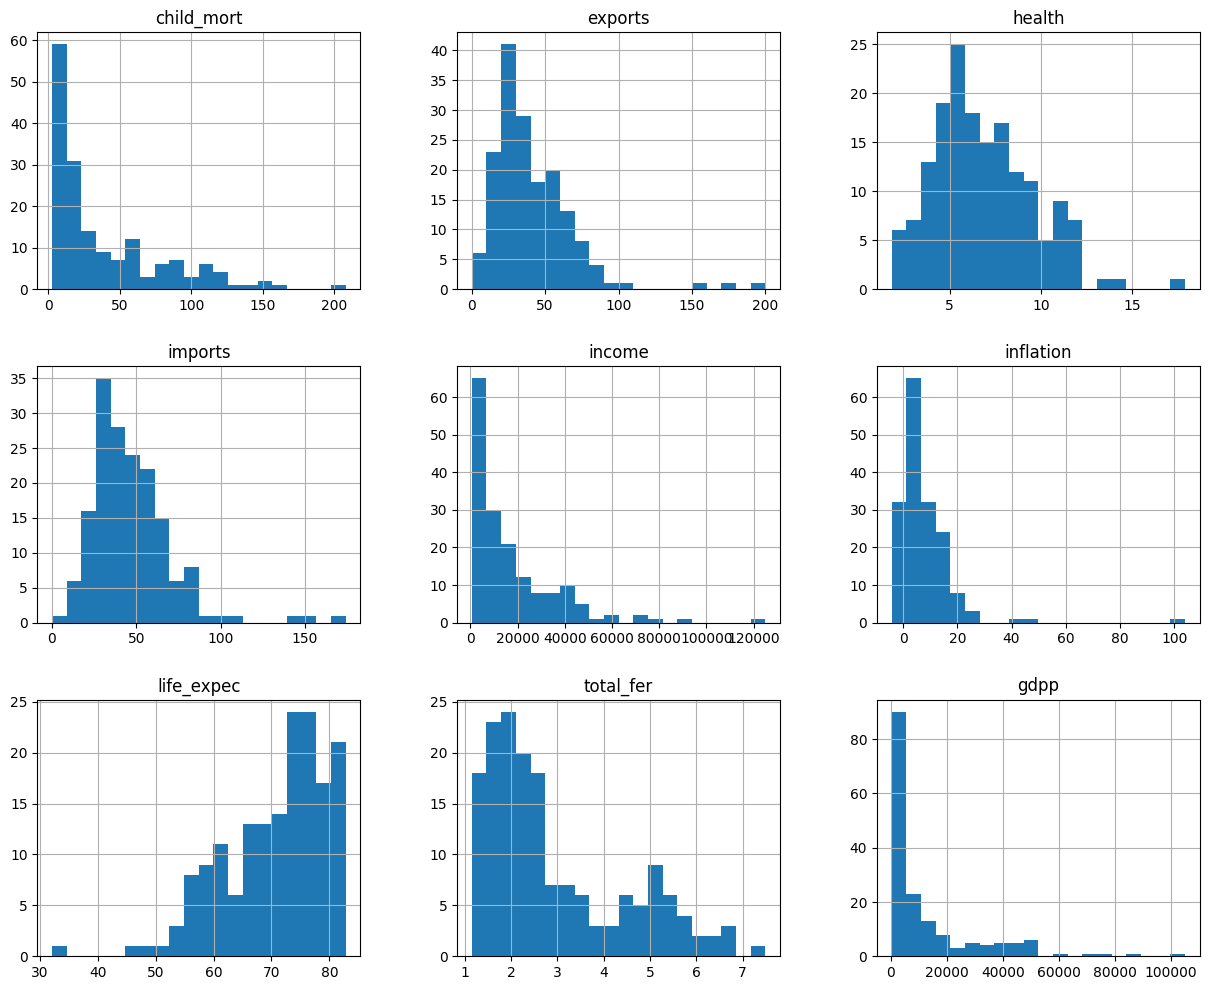

In [8]:
numeric=df.drop("country",axis=1)
numeric.hist(
    figsize=(15,12),
    bins=20
)
plt.show()

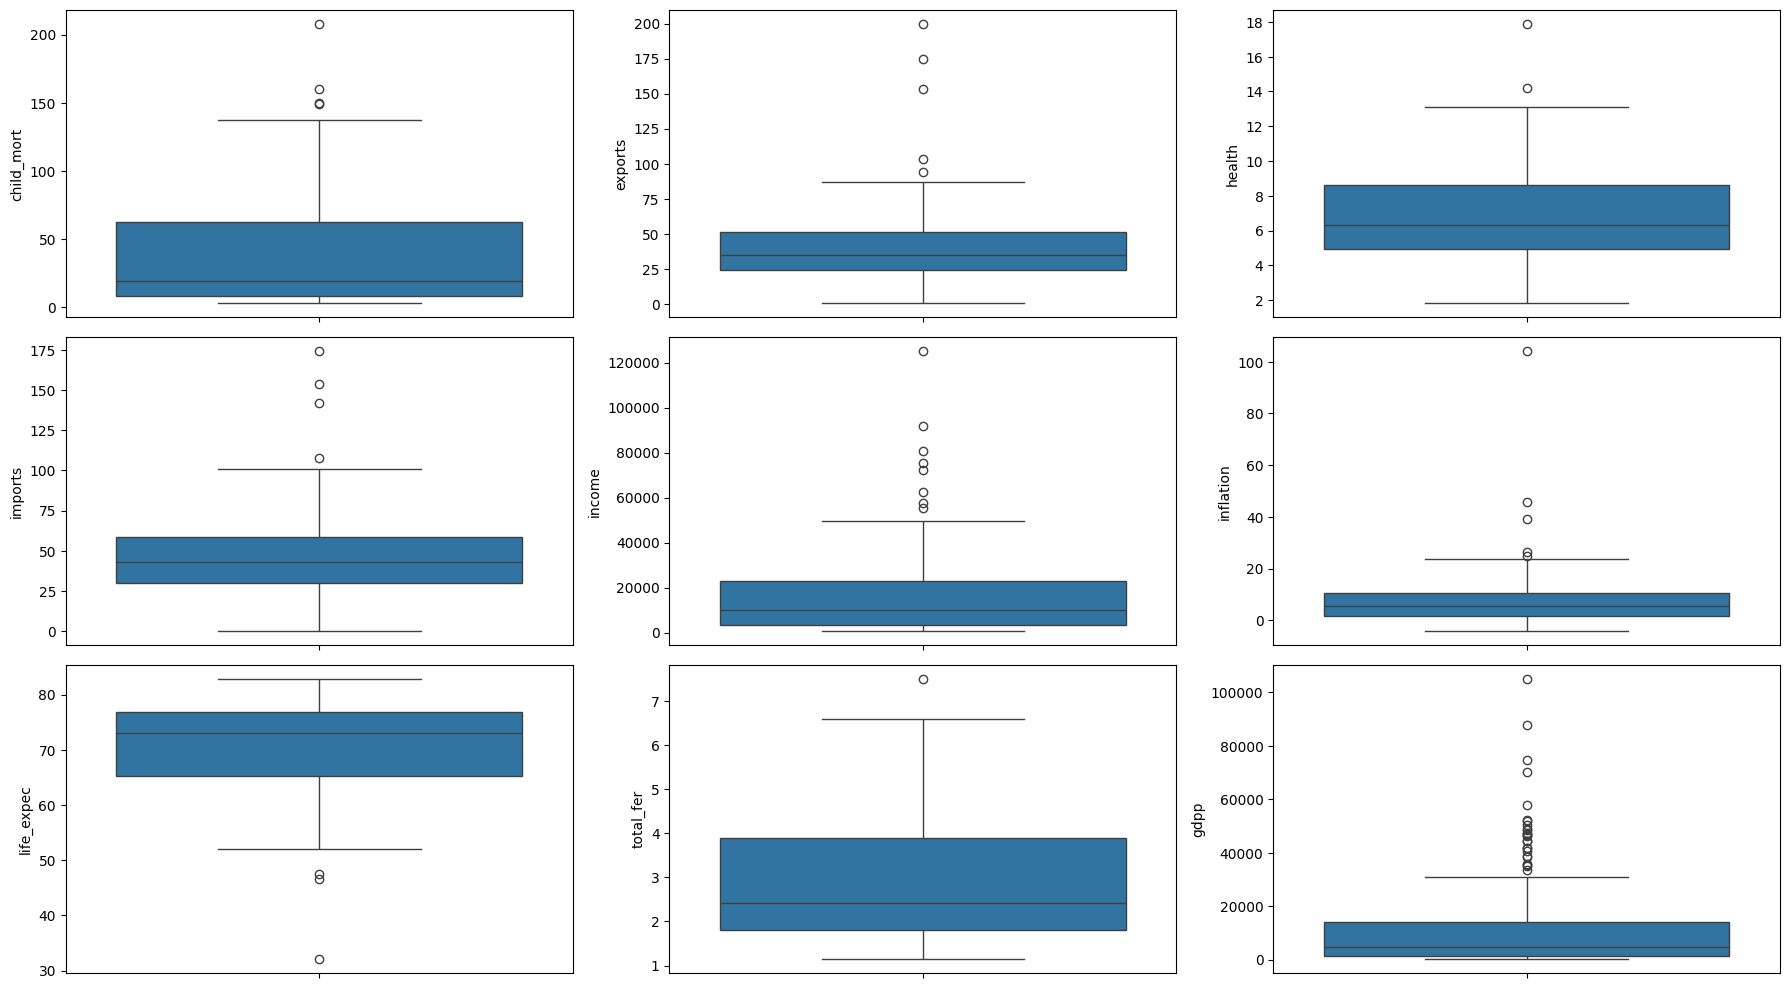

In [9]:
plt.figure(figsize=(18,10))
for i,col in enumerate(numeric.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

In [10]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(numeric)
scaled_df=pd.DataFrame(
    scaled_data,
    columns=numeric.columns
)
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [11]:
pca=PCA(n_components=2)
pca_data=pca.fit_transform(scaled_df)
pca_df=pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)
pca_df.head()

,PC1,PC2
0,-2.913025,0.095621
1,0.429911,-0.588156
2,-0.285225,-0.455174
3,-2.932423,1.695555
4,1.033576,0.136659


In [12]:
print(pca.explained_variance_ratio_)

[0.4595174  0.17181626]


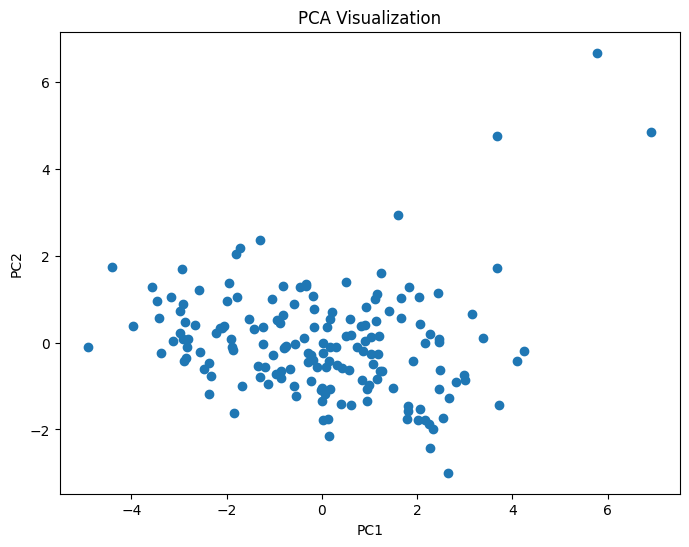

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

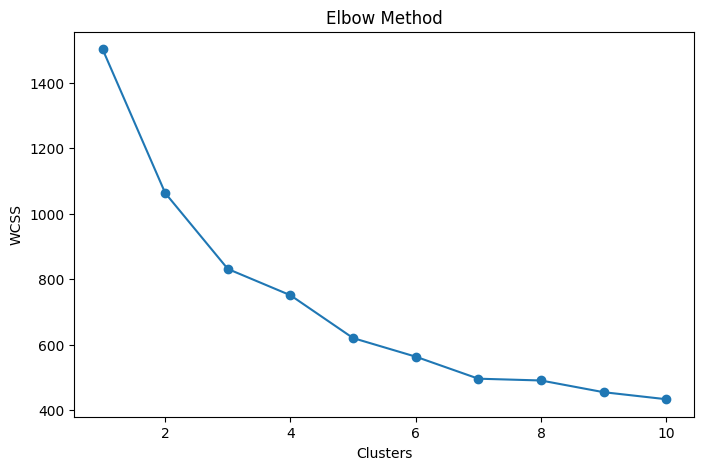

In [14]:
wcss=[]
for i in range(1,11):
    km=KMeans(
        n_clusters=i,
        random_state=42
    )
    km.fit(scaled_df)
    wcss.append(km.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [15]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42
)
df["Cluster"]=kmeans.fit_predict(scaled_df)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [16]:
score=silhouette_score(
    scaled_df,
    df["Cluster"]
)
print(score)

0.285600988953231


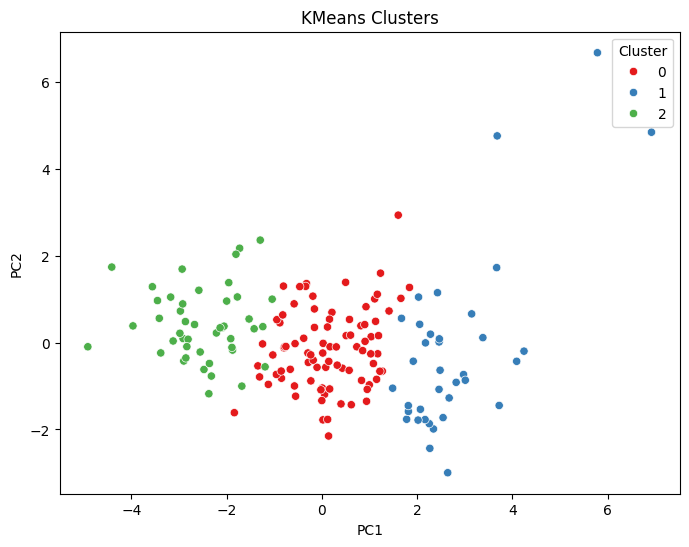

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=df["Cluster"],
    palette="Set1"
)
plt.title("KMeans Clusters")
plt.show()

In [18]:
db=DBSCAN(
    eps=1.5,
    min_samples=5
)
df["DBSCAN"]=db.fit_predict(scaled_df)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0


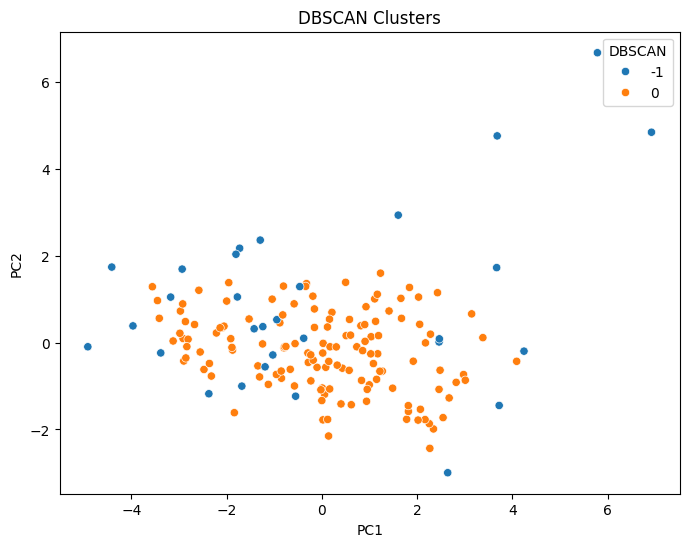

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=df["DBSCAN"],
    palette="tab10"
)
plt.title("DBSCAN Clusters")
plt.show()

In [20]:
X=scaled_df
y=df["Cluster"]

In [21]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
rf=RandomForestClassifier(
    random_state=42
)
rf.fit(
    X_train,
    y_train
)
pred_rf=rf.predict(X_test)

In [23]:
print("Accuracy")
print(
accuracy_score(
y_test,
pred_rf
)
)
print(classification_report(
y_test,
pred_rf
))

Accuracy
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



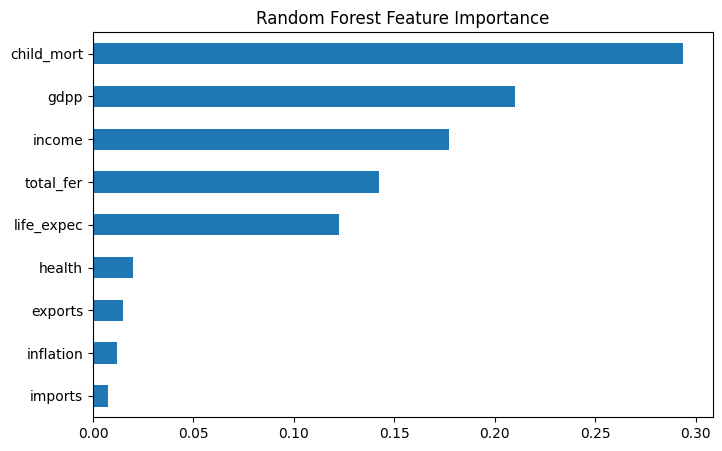

In [24]:
importance=pd.Series(
rf.feature_importances_,
index=X.columns
)
importance.sort_values().plot(
kind="barh",
figsize=(8,5)
)
plt.title("Random Forest Feature Importance")
plt.show()

In [25]:
!pip install xgboost

In [32]:
xgb=XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)
xgb.fit(
    X_train,
    y_train
)
pred_xgb=xgb.predict(X_test)

In [33]:
comparison=pd.DataFrame({
"Model":["Random Forest","XGBoost"],
"Accuracy":[
accuracy_score(
y_test,
pred_rf
),
accuracy_score(
y_test,
pred_xgb
)
]
})
comparison

,Model,Accuracy
0,Random Forest,1.0
1,XGBoost,1.0


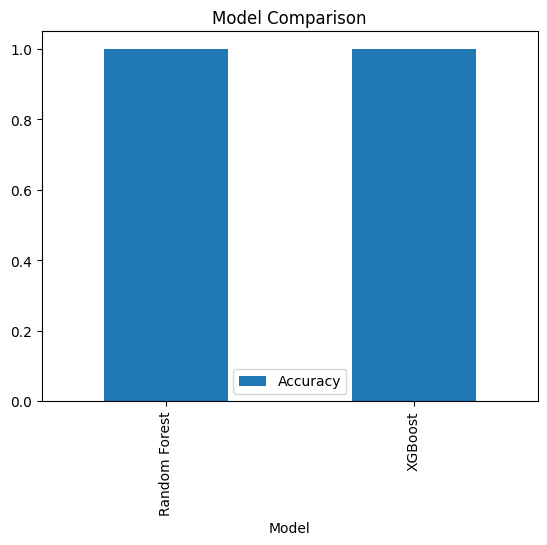

In [29]:
comparison.plot(
x="Model",
y="Accuracy",
kind="bar"
)
plt.title("Model Comparison")
plt.show()

In [30]:
df.groupby("Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN
Cluster,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,-0.069767
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,-0.333333


In [31]:
for i in sorted(df["Cluster"].unique()):
    print("\nCluster",i)
    print(df[df["Cluster"]==i]["country"].values)


Cluster 0
['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Azerbaijan' 'Bahamas' 'Bangladesh' 'Barbados' 'Belarus' 'Belize'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Bulgaria' 'Cambodia' 'Cape Verde' 'Chile' 'China' 'Colombia'
 'Costa Rica' 'Croatia' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Estonia' 'Fiji' 'Georgia' 'Grenada' 'Guatemala' 'Guyana'
 'Hungary' 'India' 'Indonesia' 'Iran' 'Iraq' 'Jamaica' 'Jordan'
 'Kazakhstan' 'Kyrgyz Republic' 'Latvia' 'Lebanon' 'Libya' 'Lithuania'
 'Macedonia, FYR' 'Malaysia' 'Maldives' 'Mauritius'
 'Micronesia, Fed. Sts.' 'Moldova' 'Mongolia' 'Montenegro' 'Morocco'
 'Myanmar' 'Nepal' 'Oman' 'Panama' 'Paraguay' 'Peru' 'Philippines'
 'Poland' 'Romania' 'Russia' 'Samoa' 'Saudi Arabia' 'Serbia' 'Seychelles'
 'Solomon Islands' 'Sri Lanka' 'St. Vincent and the Grenadines' 'Suriname'
 'Tajikistan' 'Thailand' 'Tonga' 'Tunisia' 'Turkey' 'Turkmenistan'
 'Ukraine' 'Uruguay' 'Uzbekistan' 'Vanuatu' 'Venezuela